# Fine-Tuning YOLOv12

**Selamat datang!** Notebook ini adalah panduan langkah demi langkah untuk "melatih ulang" (fine-tuning)
sebuah model AI pendeteksi objek bernama **YOLOv12** dengan data sendiri.

Tidak masalah kalau Anda **belum pernah coding sama sekali**. Setiap baris kode akan dijelaskan dengan
bahasa yang sederhana. Anda cukup menekan tombol ▶️ *Run* pada setiap sel dari atas ke bawah.

### Apa itu "Fine-Tuning"?
Fine-tuning artinya mengambil model yang sudah pintar (sudah dilatih sebelumnya), lalu melatihnya **lagi**
dengan data khusus milik kita, supaya model menjadi ahli pada tugas kita.


# Fase 1: Persiapan Lingkungan (Setup)

Sebelum bekerja, kita harus menyiapkan lingkungan kerja dulu. Bayangkan ini seperti menyiapkan
meja dan alat sebelum mulai memasak. Ada 3 langkah: cek mesin, siapkan folder, dan pasang alat (library).


### 1.1. Cek Ketersediaan GPU (Kartu Grafis)

**GPU** adalah "otak" khusus yang sangat cepat untuk melatih AI. Perintah di bawah memeriksa apakah
kita punya akses ke GPU. Tanda `!` di awal berarti ini **perintah sistem**, bukan kode Python biasa.
Anda hanya perlu menjalankan sel ini, lalu melihat apakah ada baris berisi nama GPU (mis. `Tesla T4`).


In [ ]:
!nvidia-smi

Thu Jul  9 02:46:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 1.2. Tentukan Folder Kerja (HOME)

Kita akan menggunakan variabel bernama `HOME` sebagai "alamat" folder tempat semua data dan hasil
disimpan. `os.getcwd()` artinya *get current working directory* = lihat folder tempat kita sekarang berada.


In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


### 1.3. Pasang Library yang Dibutuhkan

**Library** adalah kumpulan kode siap pakai yang dibuat orang lain, supaya kita tidak perlu menulis semuanya
dari nol. Di sini kita memasang:

- **`ultralytics`** — alat utama untuk menggunakan dan melatih YOLO.
- **`supervision`** — alat bantu memproses hasil deteksi.
- **`roboflow`** — alat untuk mengunduh dataset (gambar + label) dari Roboflow.

Baris `%pip install` memerintahkan Python untuk memasangnya. Ini hanya perlu dijalankan **sekali**.


In [ ]:
%pip install -q "ultralytics>=8.4.0" supervision roboflow

# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.9/112.6 GB disk)


# Fase 2: Menyiapkan Dataset untuk Fine-Tuning

**Dataset** adalah kumpulan gambar beserta keterangan (label) lokasi objek di dalam gambar.
Model belajar dari dataset ini.

Kita mengunduh dataset dari **Roboflow Universe** (kumpulan dataset publik).
Saat program meminta *authentication token*, ikuti petunjuk:
1. Buka link yang muncul dan login ke akun Roboflow.
2. Salin token, lalu tempel (paste) di kotak input dan tekan Enter.

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
import roboflow

roboflow.login()
rf = roboflow.Roboflow()

project = rf.workspace("orbit-future-academy-o5orz").project("eye-detection-9rzmy")
version = project.version(3)
dataset = version.download("yolov12")

/content/datasets
visit https://app.roboflow.com/auth-cli to get your authentication token.
Paste the authentication token here: ··········
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to eye-detection-3 in yolov12:: 100%|██████████| 6257/6257 [00:00<00:00, 9021.90it/s]


# Fase 3: Melatih Model (Custom Training)

Ini adalah **inti** dari notebook ini — saat model "belajar" dari dataset. Mari kita pahami perintahnya:

- `task=detect` → jenis tugas: mendeteksi objek.
- `mode=train` → mode: melatih (bukan memprediksi).
- `model=yolo12n.pt` → model awal: YOLOv12 versi nano (kecil & cepat), yang akan kita *fine-tune*.
- `data=.../data.yaml` → alamat file yang menjelaskan lokasi dataset.
- `epochs=20` → jumlah putaran belajar (20 kali melihat seluruh data).
- `imgsz=320` → ukuran gambar yang dipakai (320 × 320 piksel).
- `plots=True` → membuat grafik hasil pelatihan secara otomatis.

💡 *Catatan edukasi:* Saat training, **preprocessing** (mengubah ukuran & normalisasi gambar) dan
**data augmentation** (memanipulasi gambar seperti memutar/zoom agar model lebih tangguh) sudah
**dilakukan otomatis** oleh Ultralytics. Anda tidak perlu menuliskannya manual.


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo12n.pt data={dataset.location}/data.yaml epochs=20 imgsz=320 plots=True

/content
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/eye-detection-3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

### Melihat Hasil Training

Hasil training disimpan otomatis di folder `runs/detect/train/`. Mari kita lihat isinya dan tampilkan
beberapa grafik penting:


Kode di bawah menampilkan **confusion matrix** — tabel yang menunjukkan seberapa benar model mengenali setiap kelas objek.

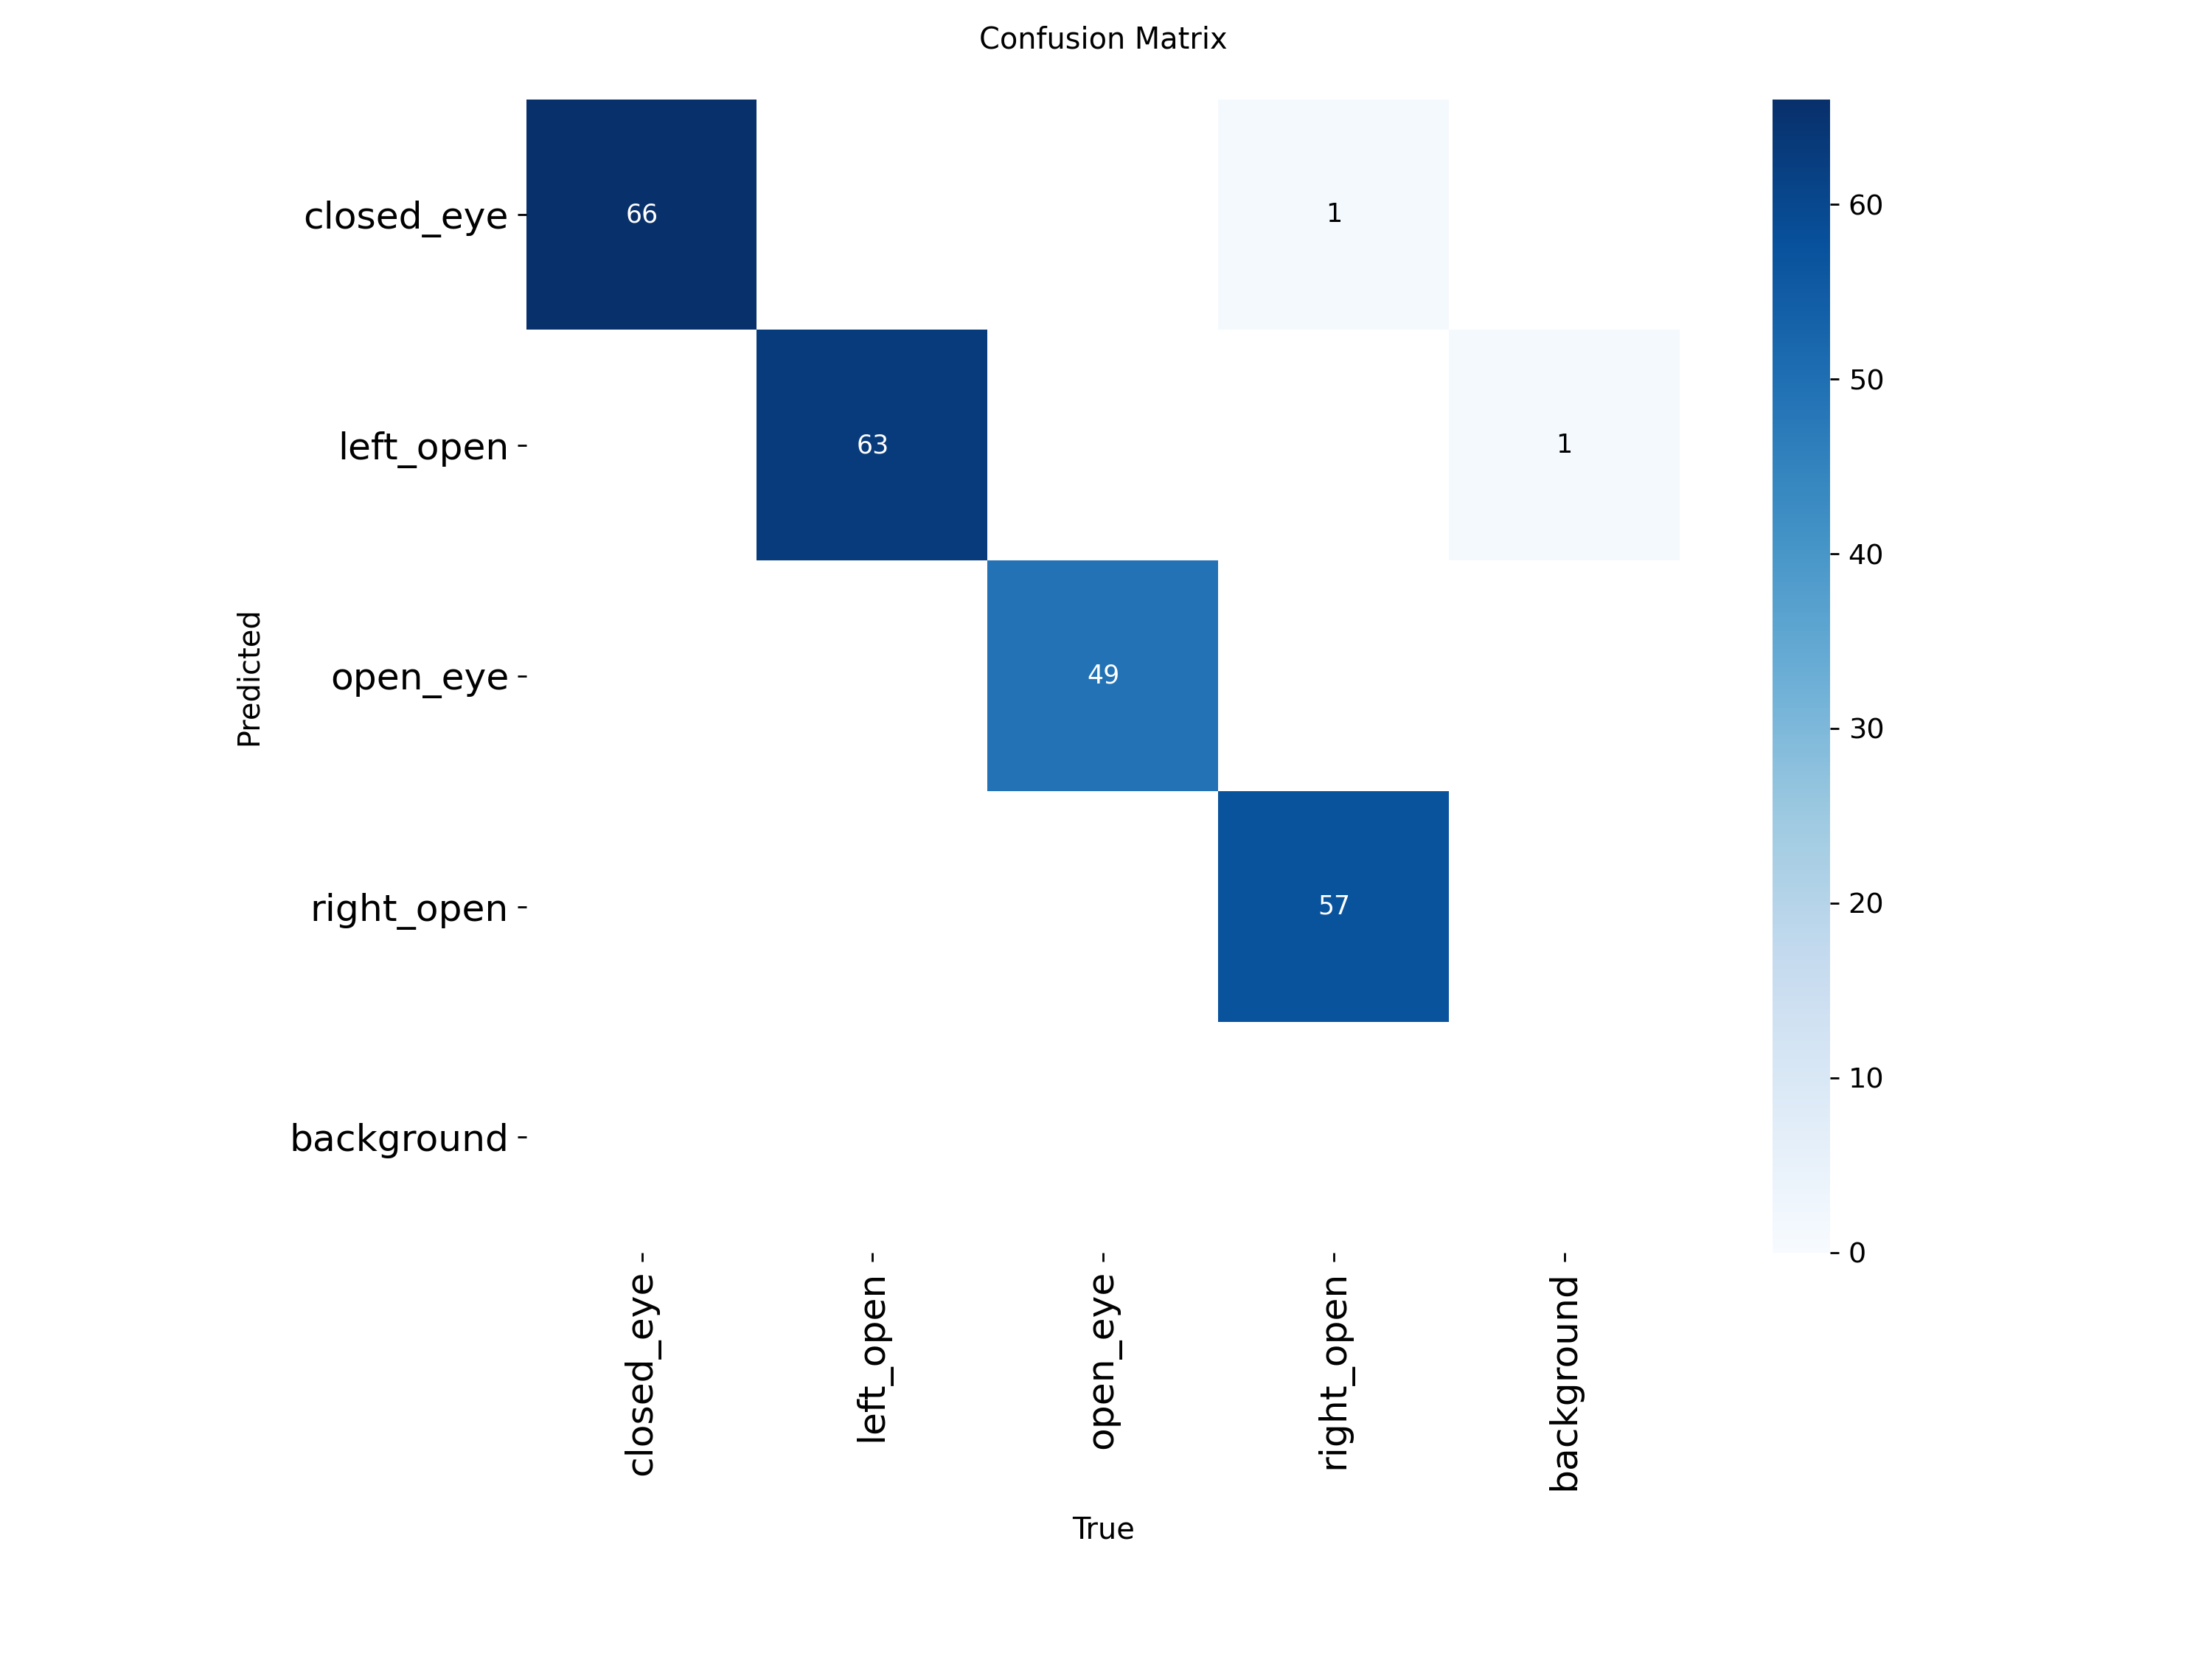

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

**Grafik akurasi & loss** (`results.png`) — memperlihatkan kemampuan model meningkat dari waktu ke waktu.

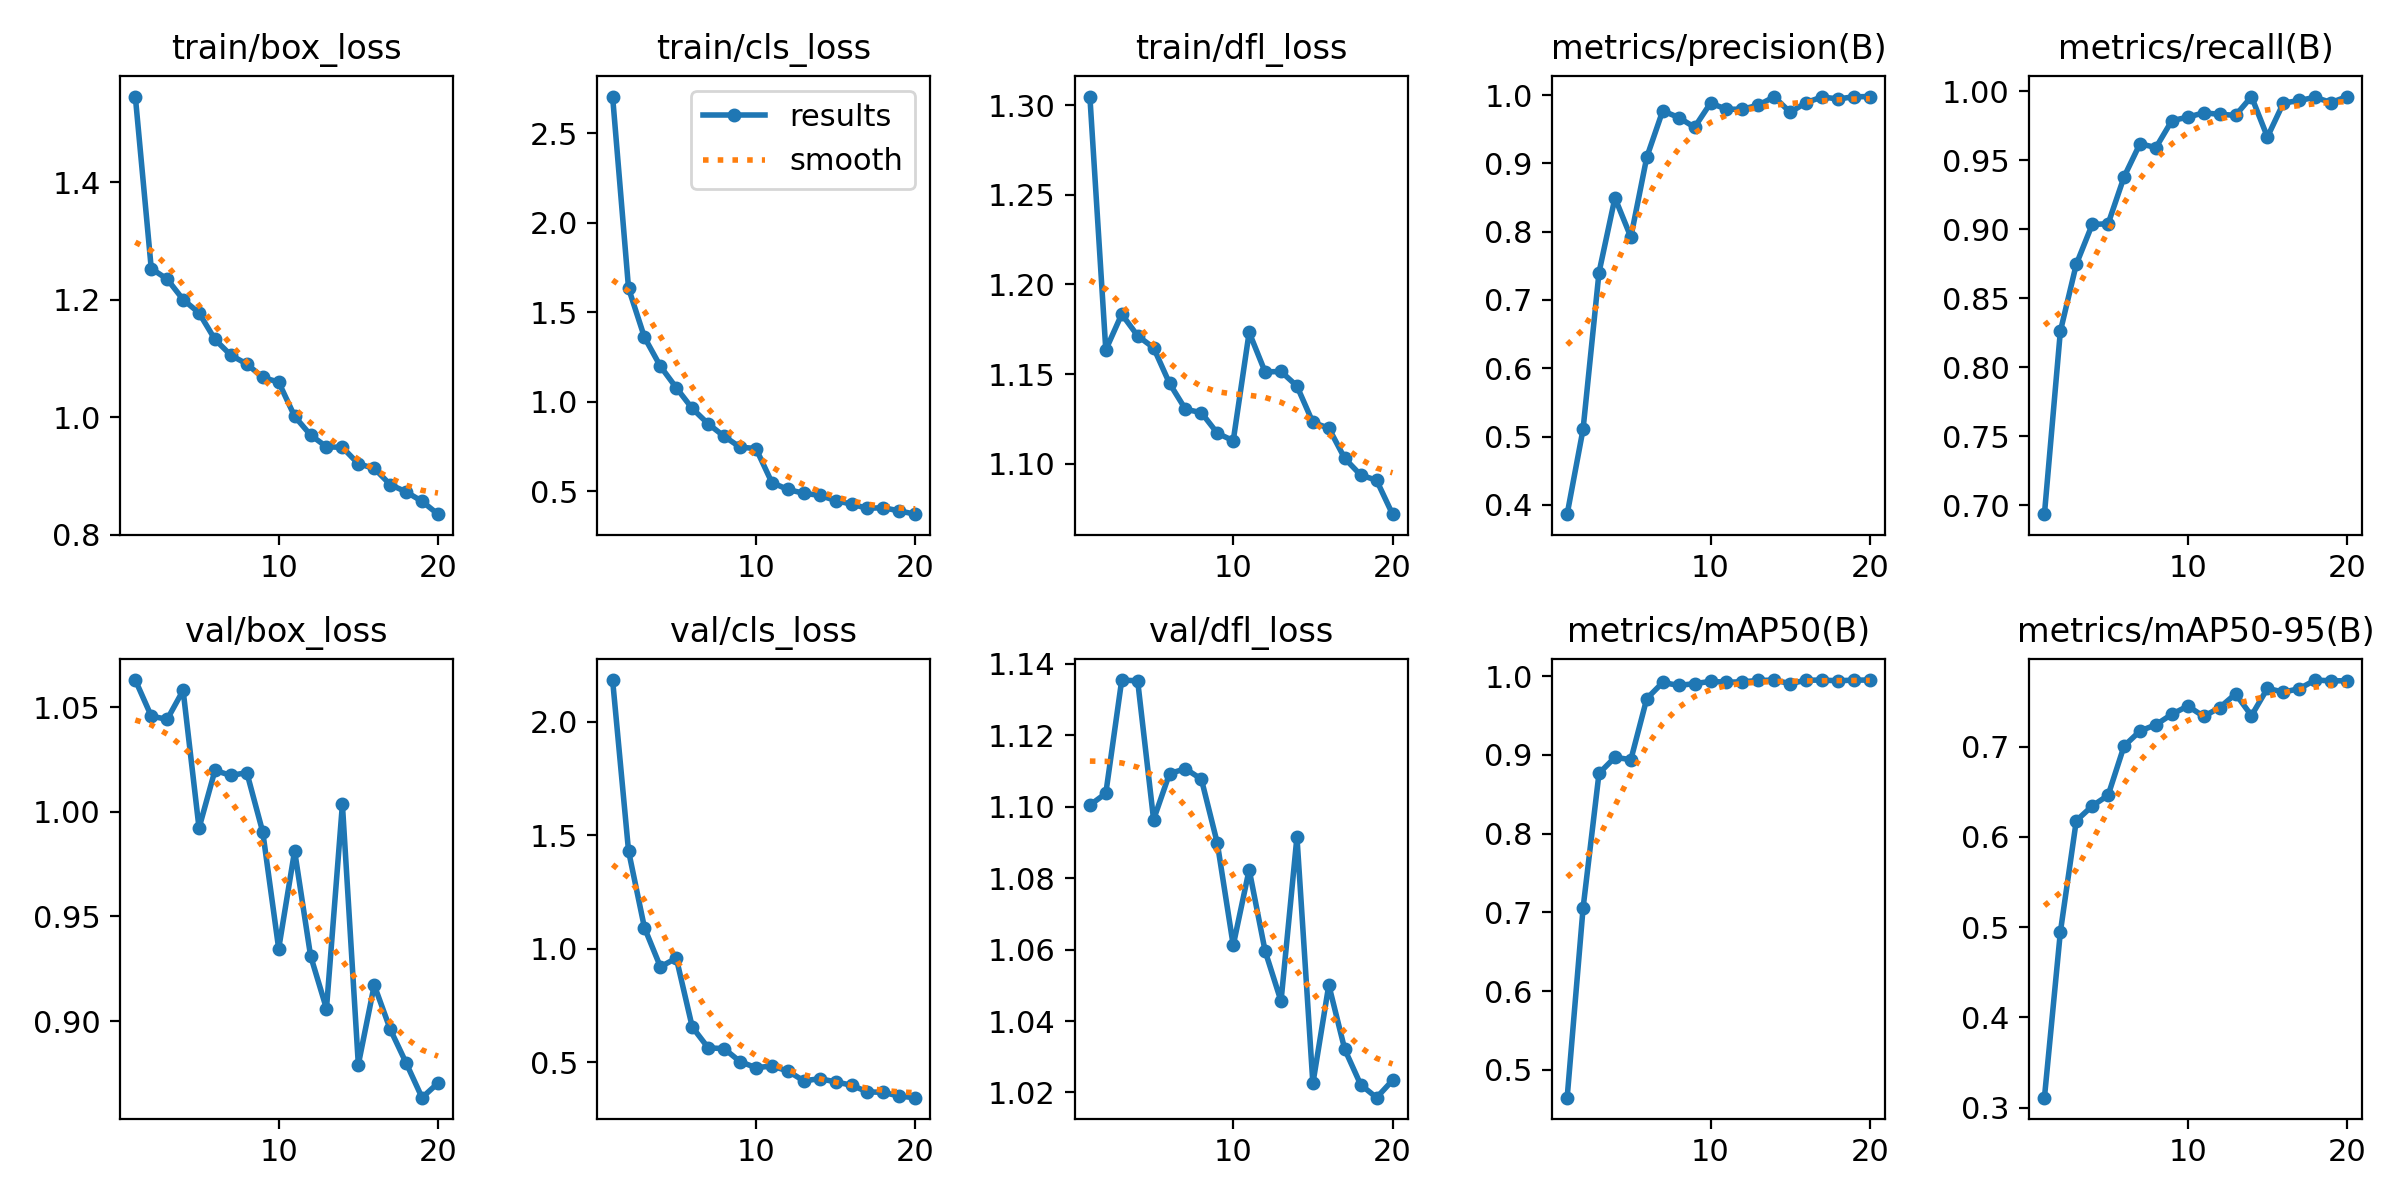

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

# Fase 4: Validasi Model yang Telah Dilatih

**Validasi** = menguji kehebatan model dengan data yang *belum pernah dilihatnya* selama training.
Ini memberi tahu kita metrik seperti `mAP50` (semakin tinggi mendekati 1, semakin baik).


In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,508 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1282.4±270.6 MB/s, size: 26.3 KB)
val: Scanning /content/datasets/eye-detection-3/valid/labels.cache... 236 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 236/236 45.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 7.0it/s 2.1s
                   all        236        236      0.994      0.996      0.994      0.772
            closed_eye         66         66      0.983          1      0.992      0.771
             left_open         63         63      0.996          1      0.995      0.771
              open_eye         49         49      0.999          1      0.995      0.746
            right_open         58         58      0.999      0.983      0.995      0.798
Speed: 0.4ms preprocess, 2.4

# Fase 5: Ekspor Model ke Format ONNX

**ONNX** adalah format file agar model bisa dipakai di banyak platform (web, aplikasi, perangkat lain).
Kita mengubah model `.pt` menjadi `.onnx`, lalu mengunduhnya ke komputer kita.


In [ ]:
# !yolo export model={HOME}/runs/detect/train/weights/best.pt format=onnx imgsz=320
!yolo export model={HOME}/runs/detect/train/weights/best.pt format=onnx imgsz=320
from google.colab import files
files.download(f'{HOME}/runs/detect/train/weights/best.onnx')

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv12n summary (fused): 159 layers, 2,590,824 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from '/content/yolo12n.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 84, 2100) (5.3 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.3s, saved as '/content/yolo12n.onnx' (10.1 MB)

Export complete (2.6s)
Results saved to /content/yolo12n.onnx
Predict:         yolo predict task=detect model=/content/yolo12n.onnx imgsz=320 
Validate:        yolo val task=detect model=/content/yolo12n.onnx imgsz=320 data=None  
Visualize:       https://netron.app
💡 Learn more at https://docs.ultralytics.com/modes/export


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Fase 6: Periksa & Unduh Daftar Class

Terakhir, kita melihat **daftar kelas** (nama objek) yang dikenali model, lalu menyimpannya ke file
`classes.json` dan mengunduhnya. Berguna saat model dipakai di aplikasi lain.


In [ ]:
import json
from ultralytics import YOLO
from google.colab import files

model = YOLO(f'{HOME}/runs/detect/train/weights/best.pt')

class_list = list(model.names.values())

file_path = f'{HOME}/runs/detect/train/weights/classes.json'
with open(file_path, 'w') as f:
    json.dump(class_list, f, indent=4)

print(f"File JSON berhasil dibuat di: {file_path}")

files.download(file_path)

File JSON berhasil dibuat di: /content/classes.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>